# Gaussian Sampling and Median Filtering

## Learning Objectives

Before diving into this chapter it is required that you know the necessary concepts like image formation, image filtering, image convolution as well as basics of linear algebra and statistics.

In this section you will be learning:

1. What is smoothing?
2. Role of filters in smoothing.
3. Gaussian filter as a case of linear filter.
4. Median filter as a case of non-linear filter.
5. Applications of smoothing filter


## Smoothing

You are already familiar with the process of noise and how it affects the image. There are different types of noise that can be present in an image. But most of the time you will be dealing with ways to filter these and extract the relevant part of the image you are interested in.

Smoothing is one such technique of noise filternation that is used to to clean up the sharp noises present within the image. Smoothing has several applications in the domain of image processing and among these applications are those with countour extraction, aliasing effect and reduction of sharp regions.

Smoothing typically involves use of lowpass filters. Once you have deep understanding with low pass filters, it won't be that difficult to understand other filters like high pass filters (used in sharpening), band pass and band reject filters.

Among different types of filter used in smoothing, this chapter you make you familiar with gaussian filtering (smoothing) and median filtering.


## Gaussian Sampling

Before directly jumping into the context of box fitlering, there are some terminologies and mathematics that you should cover to understand the materials thoroughly.

### Introduction

Gaussian sampling or filtering is a linear filtering technique that use gaussian kernel. These filters are used to remove noise and throw away the finer details that may act as noise in further image processing. In any case you are focused on extracting a coarser detail and feature at a higher abstraction, then you can simply use this filtering method.



### Mathematical Formulation

To understand gaussian kernel, let's do a quick review on gaussian probability density fucntion. It can be given as follows:

$$
    p(z) = \frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(z - \bar{z})^2}{2\sigma^2}}, - \infty < z < \infty
$$
Here $\bar{z}$ is the mean and $\sigma^2$ is the variance.
You can extend the idea into 2D gaussian distribution which can be given as:
$$
    w(s, t) = G(s, t) = Ke^{-\frac{s^2 + t^2}{2\sigma^2}} = Ke^{-\frac{r^2}{2\sigma^2}}
$$
Notice, $r = \sqrt{s^2 + t^2}$ is the can be viewed as the distance from the center of the function to any point on the function.

For 3x3 kernel, you can picture $r$ as,
$$
r =
\begin{pmatrix}
\sqrt{2} & 1 & \sqrt{2} \\
1& 0 & 1 \\
\sqrt{2} & 1 & \sqrt{2}
\end{pmatrix}
$$
**Note**: representing the r in matrix for better visualization.

Varying the value of z and sigma gives us distributions with different bell curve shape. For a kernel of size $m \times m$, r can be estimated as:
$$
    r^2_{max} = \frac{(m-1)^2}{2}
$$

In case of gaussian kernel, $\sigma$ is also called the scale factor. Sampling the gaussian function gives the kernel. The value of kernel depends on the value of K and scale, $\sigma$

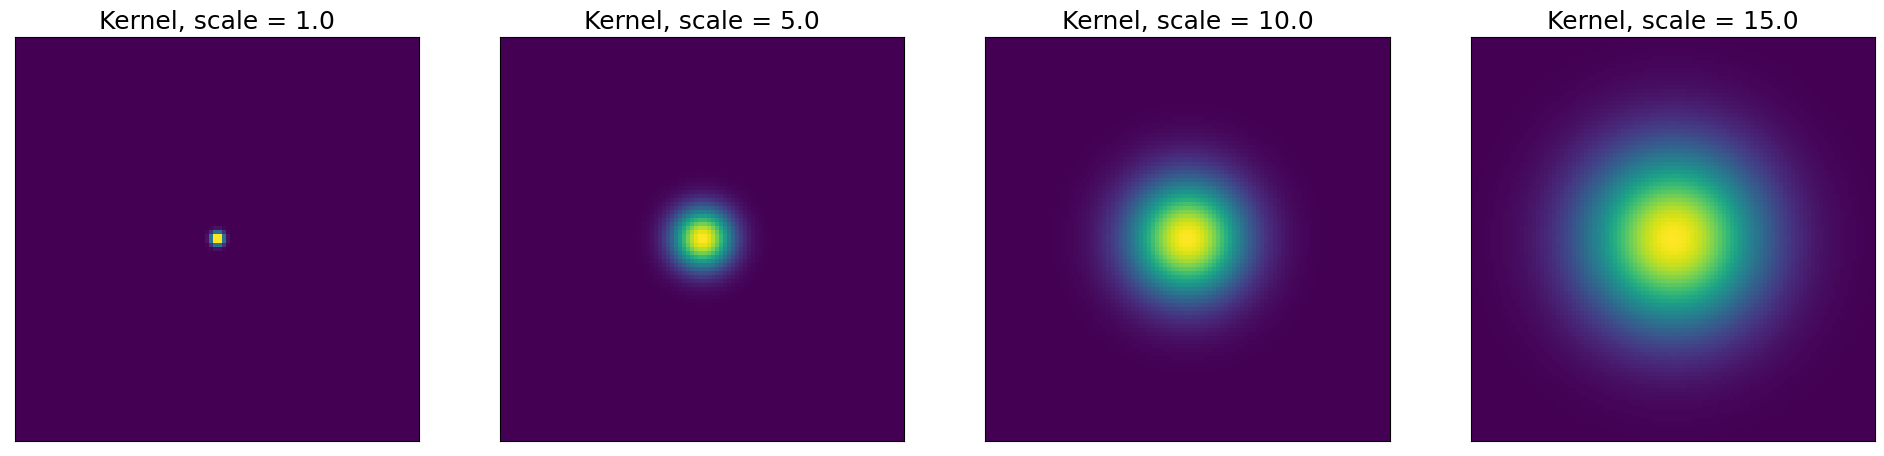

In [ ]:
#@title Gaussian Kernel
import matplotlib.pyplot as plt
import numpy as np
def plot_images(images, size=(12, 9)):
    num = len(images)
    fig, ax = plt.subplots(nrows=1, ncols=num)
    fig.set_dpi(100)
    fig.set_size_inches(size)
    for i, info in enumerate(images):
        ax[i].set_title(info["title"], fontsize=18)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].imshow(info["image"])
    plt.show()


def gkernel(shape=(3,3),sigma=1):
    """
    2D gaussian mask
    """
    m,n = [(ss-1.)/2. for ss in shape]
    y,x = np.ogrid[-m:m+1,-n:n+1]
    h = np.exp( -(x*x + y*y) / (2.*sigma*sigma) )
    h[ h < np.finfo(h.dtype).eps*h.max() ] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

images = [{ 'title': "Kernel, scale = 1.0", 'image': gkernel((100, 100), 1)},
          { 'title': "Kernel, scale = 5.0", 'image': gkernel((100, 100), 5)},
          { 'title': "Kernel, scale = 10.0", 'image': gkernel((100, 100), 10)},
          { 'title': "Kernel, scale = 15.0", 'image': gkernel((100, 100), 15)}]

plot_images(images, size=(24, 18))

<center>
<!-- <img src="https://cdn-images-1.medium.com/max/1024/1*t3FyQ5PyBzc4mWQGvxO1Wg.gif"> -->
<img src="https://i.postimg.cc/RhZct2rr/latest-3.gif"/>
</img>
<figcaption>Fig 1. Gaussian Blur</figcaption>
Source: Gaussian Blur (Bitcoin Insider)
</center>

In the above animation, we can see the simple demonstration of how a gaussian blur takes place. Here, we determine the size of a kernel. And, on the basis of the kernel, we convolve to the original image matrix and calculate the average of pixels situated inside the kernel. In this way, we obtain the resulting gaussian blur matrix.

## Implementation

In this section we are going to implement gaussian smoothing and see how affects the image with noise.

In [ ]:
!curl -q "https://upload.wikimedia.org/wikipedia/commons/thumb/0/01/Souvenirs_de_L%C3%A9onard_1905_cover_portrait_%28adjusted%29.jpg/445px-Souvenirs_de_L%C3%A9onard_1905_cover_portrait_%28adjusted%29.jpg" -o image.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 47232  100 47232    0     0   299k      0 --:--:-- --:--:-- --:--:--  301k


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
def plot_images(images, size=(12, 9)):
    num = len(images)
    fig, ax = plt.subplots(nrows=1, ncols=num)
    fig.set_dpi(100)
    fig.set_size_inches(size)
    for i, info in enumerate(images):
        ax[i].set_title(info["title"], fontsize=18)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].imshow(info["image"])
    plt.show()

Shape of image: (480, 445, 3)


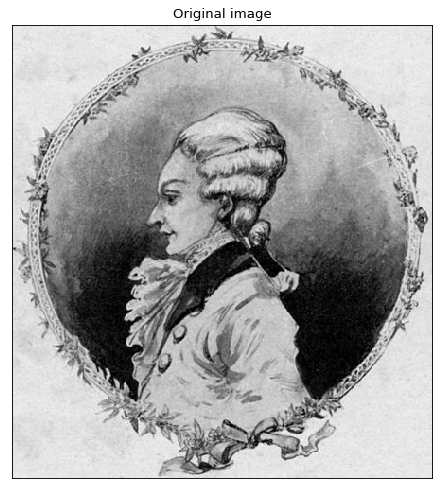

In [ ]:
image = cv2.imread("image.jpg")
image1 = image.copy()
print(f"Shape of image: {image.shape}")
dpi = 80
margin = 0.05 # (5% of the width/height of the figure...)
xpixels, ypixels = image.shape[0:2]
# Make a figure big enough to accomodate an axis of xpixels by ypixels
# as well as the ticklabels, etc...
figsize = (1 + margin) * ypixels / dpi, (1 + margin) * xpixels / dpi
fig = plt.figure(figsize=figsize, dpi=dpi)
# Make the axis the right size...
ax = fig.add_axes([margin, margin, 1 - 2*margin, 1 - 2*margin])
ax.set_title("Original image")
ax.imshow(image, interpolation='none')
plt.xticks([]), plt.yticks([])
plt.show()

# Median Filtering

## Introduction

Sometimes you may feel like using non-linear function as a kernel. In such cases, you may want to replace some pixels with the maximum value from the neighboring pixels. You can do this in different ways, using different order-statistics functions. However, in this chapter you will be learning about median filtering.

One key factor that sets median filtering apart is how this filter tries to preserve the original structure of the image.

As you have seen in earlier section, how median filter was effective in removing the salt and paper noise present within in the image. Other than salt and pepper noise, there are different types of random noise for which this filtering technique can be highly effect.

<center>
<!-- <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/ae/Median_filter_2D.gif/551px-Median_filter_2D.gif"> -->
<img src="https://i.postimg.cc/g0yRTGmF/latest-4.gif"></img>
<figcaption>Fig 2. Median Blur</figcaption>
Source: Median Blur (Wikimedia)
</center>

In the figure 2, we can see the implementation of the median blur. Here, we take a kernel and on that kernel we sort the values present and calculate the median to update on the output matrix.

In [ ]:
#@title Median Filtering Process
import numpy as np
import matplotlib.pyplot as plt



## Mathematical Formulation

The central idea in this filter is to replace every image pixel by median of it's neighbors. If you select some region say, $3\times3$ filter , you will replacing pixel at location _(u,v)_ with the median of pixels covered by the filter in image I. i.e,

$$
    I'(u,v) = median\{I(u + i, v + j)\}, \text{for all}\ (i,j) \in R
$$

To find the median for pixels, you sort these pixels bounded by the region of the filter and determine the median.


## Implementation

Let's try applying median filtering to the above image.

In [ ]:
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=19K0snUO-n2w1RBIXNLwBsz7GZ_LvzVJC' -O input.png

Shape of image: (543, 406, 3)


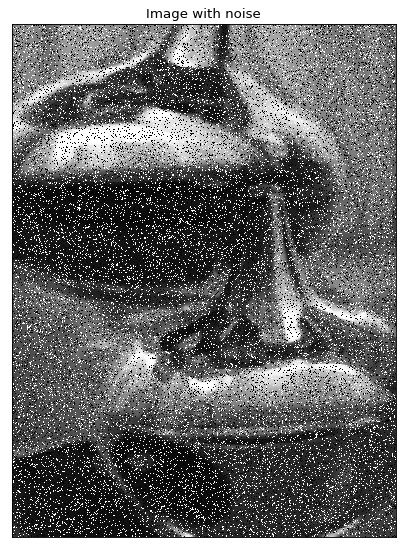

In [ ]:
image = cv2.imread("input.png")
image2 = image.copy()
print(f"Shape of image: {image.shape}")
dpi = 80
margin = 0.05 # (5% of the width/height of the figure...)
xpixels, ypixels = image.shape[0:2]

# Make a figure big enough to accomodate an axis of xpixels by ypixels
# as well as the ticklabels, etc...
figsize = (1 + margin) * ypixels / dpi, (1 + margin) * xpixels / dpi

fig = plt.figure(figsize=figsize, dpi=dpi)
# Make the axis the right size...
ax = fig.add_axes([margin, margin, 1 - 2*margin, 1 - 2*margin])
ax.set_title("Image with noise")
ax.imshow(image, interpolation='none')
plt.xticks([]), plt.yticks([])
plt.show()

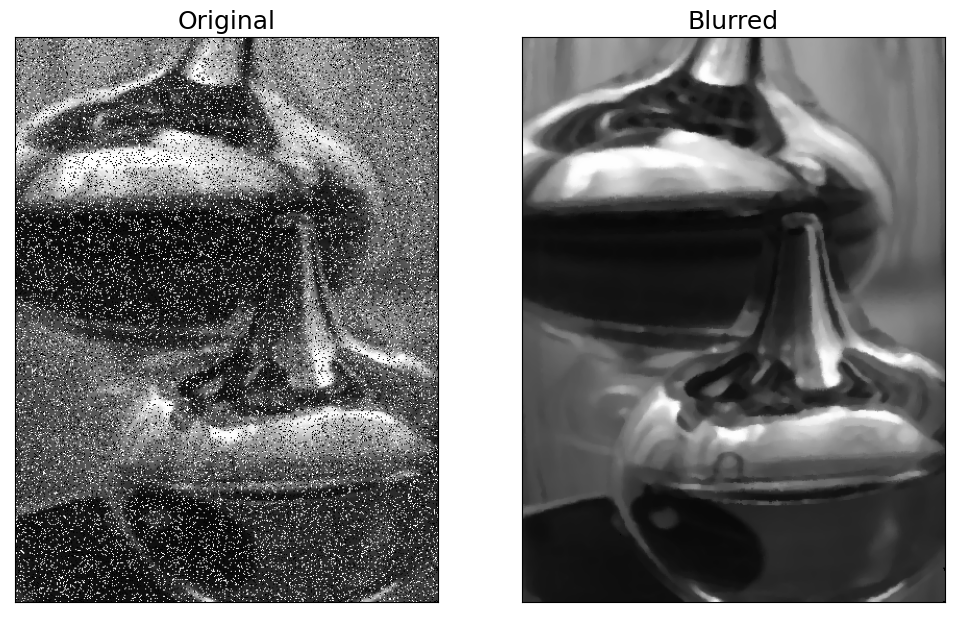

In [ ]:
blurred = cv2.medianBlur(image,5)
images = [{ 'title': "Original", 'image': image},
          { 'title': "Blurred", 'image': blurred}]
plot_images(images)

#Comparision between Gaussian Filtering and Median Filtering

In this section we will apply different type of filtering to both of our input image to get the idea of application.

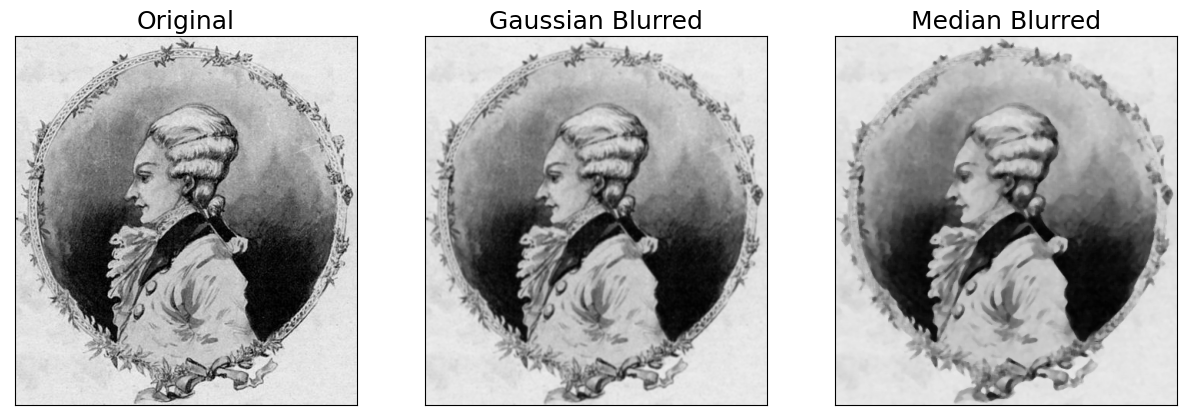

In [ ]:
# Case for input image 1
gblurred = cv2.GaussianBlur(image1,(5,5), sigmaX=1, sigmaY=1)
mblurred = cv2.medianBlur(image1,5)
images = [{ 'title': "Original", 'image': image1},
          { 'title': "Gaussian Blurred", 'image': gblurred},
          { 'title': "Median Blurred", 'image': mblurred}]
plot_images(images, size=(15, 12))

In the above figure you should observe that there are less details in the image obtained after median filtering compared to gaussian filtering. In gaussian filtering it smoothens the sharp regions making image smoother and natural. However, it still looses some fine details.

To see the details of the effect, refer to the code below.

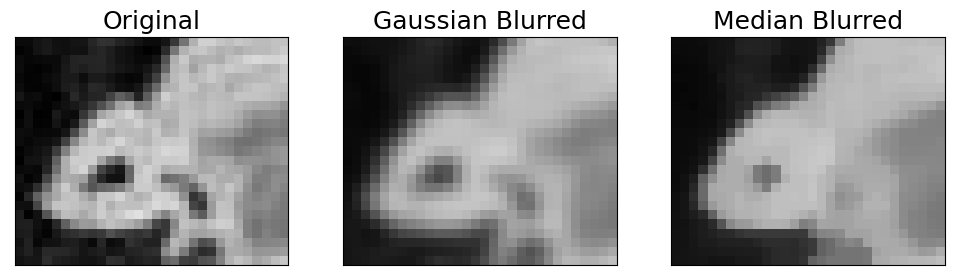

In [ ]:
images = [{ 'title': "Original", 'image': image1[250:275, 120:150]},
          { 'title': "Gaussian Blurred", 'image': gblurred[250:275, 120:150]},
          { 'title': "Median Blurred", 'image': mblurred[250:275, 120:150]}]
plot_images(images)

In this figure, gaussian filtering method just smoothens out the sharp cuts to make the image more smooth. It also removes some small noise in this process. This is apparent from the above image.

In case of median filtering, it samples the median, as a result the shape of the detail changes significantly. Notice the size of hole in the median blurred image. It simply makes it difficult to see the button. Looking at this hole, we can see that the median blur is trying to generalize the pixel with its neighbouring pixels. But, while doing so, it is missing out the hole. Comparatively, the image is smoother while missing out some details.

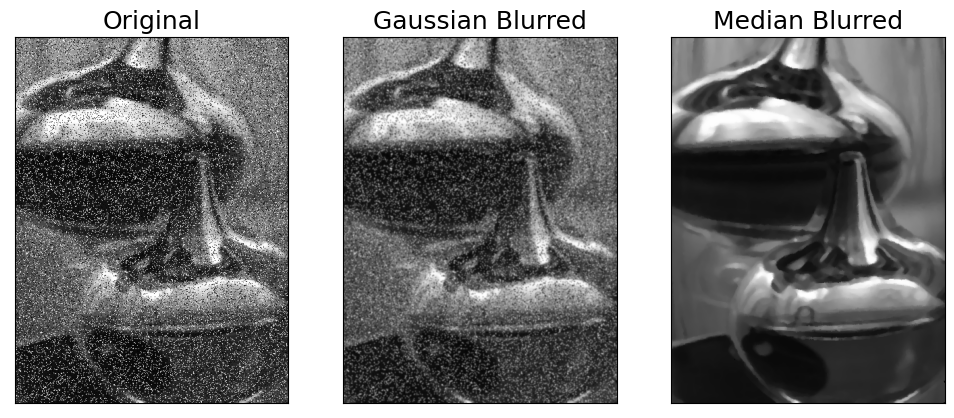

In [ ]:
gblurred2 = cv2.GaussianBlur(image2,(5,5), sigmaX=0.8, sigmaY=0.8)
mblurred2 = cv2.medianBlur(image2,5)
images = [{ 'title': "Original", 'image': image2},
          { 'title': "Gaussian Blurred", 'image': gblurred2},
          { 'title': "Median Blurred", 'image': mblurred2}]
plot_images(images)

However in case of salt and pepper noise, median filter plays significant role in more in removing image. Despite modifying the details it can make sure you have a clear image, which is closet to the original image. Unlike in case of gaussian filtering, where the noise is smoothened but not cleared.

In conclusion, Median Filtering forces a pixel to be more like its neighbours. So, it is considerably more smooth than the averaging gaussian filter. Here, since the median filter takes the median value out of the kernel. Pixels with similar values are more likely to be closer to each other. And, when we choose the median we have a smooth image pixels lying close to one another with same image pixel intensity.

However, on the other hand, average filter takes the average of the pixel values in the kernel. Because of this reason, the pixel values differ from each other by small intensity although stay at a similar range. Due to this reason also, the average filters create sharp cuts even at the edges ultimately smoothing the edges too creating the small difference in the pixel values even with the ones close to one another.

#Key Takeaways

In this chapter you have learned the following concepts:

1. Smoothing is the process of refining the sharp regions in the image.

2. Smoothing is obtained by using low pass filter such as gaussian filter and median filter.

3. Gaussian filter is based on gaussian kernel.

4. Median filtering is based on sampling the median from a region covered by the kernel.

5. Gaussian filter is suitable for handling sharpe edges while maintaing coarse detail.

6. Median filter is suitable in situation with large amount of grain noise such as salt and pepper.